##### 실행 환경 설정

In [1]:
# Google Drive 마운트
from google.colab import drive
drive.mount("/google_drive")

# 작업 경로 설정
WORK_DIR = "/google_drive/Othercomputers/내 Mac/sec07"

print("\n[작업 폴더 목록]")
%cd "{WORK_DIR}"
!ls

Mounted at /google_drive

[작업 폴더 목록]
/google_drive/Othercomputers/내 Mac/sec07
01_dataset_dataloader.ipynb  07_transfer_learning_resnet.ipynb
02_cnn_model.ipynb	     08_transfer_learning_efficientnet.ipynb
03_train.ipynb		     datasets
04_cnn_model_gap.ipynb	     saved_models_data_augmentation
05_train_gap.ipynb	     saved_models_efficientnet
06_data_augmentation.ipynb   saved_models_resnet


##### 이전 노트북 실행

In [2]:
%%capture
get_ipython().run_line_magic("run", "02_cnn_model.ipynb")

##### 임포트

In [3]:
import torch
import copy

##### Device 설정

In [4]:
# 디바이스 설정: GPU 사용 가능하면 cuda, 아니면 cpu
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"사용 디바이스: {device}")

사용 디바이스: cuda


##### 손실 함수와 옵티마이저 생성

In [5]:
# 모델을 디바이스로 이동
model = model.to(device)

# 손실 함수: 다중 분류에 표준적으로 사용되는 CrossEntropyLoss
# - 내부적으로 Softmax + NLLLoss를 결합한 형태
# - 입력: 모델 출력 logit (batch, 10), 정답 레이블 (batch,)
loss_fn = torch.nn.CrossEntropyLoss()

# 옵티마이저: Adam
# - lr: 학습률(learning rate). 파라미터를 한 번에 얼마나 업데이트할지 결정
LEARNING_RATE = 0.001
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)

##### 학습률 스케쥴러 설정 및 EarlyStopping 설정

In [6]:

# LR 스케줄러: 검증 손실이 patience 에포크 동안 개선되지 않으면 lr을 factor 배만큼 줄임
# mode='min': 손실이 낮을수록 좋음 / factor=0.5: lr을 절반으로 감소 / patience=3: 3 에포크 기다림
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=3
)

# 조기 종료(Early Stopping) 설정
# patience: 검증 손실이 개선되지 않아도 허용할 에포크 수
# patience_counter: 개선 없이 누적된 에포크 수
# best_val_loss: 현재까지 가장 낮은 검증 손실 (초기값: 무한대)
# best_model_state: 검증 손실이 가장 낮았을 때의 모델 파라미터 복사본
PATIENCE         = 10
patience_counter = 0
best_val_loss    = float('inf')
best_model_state = None


##### 학습 함수 정의

In [7]:

def train(loader):
    """한 에포크 학습: 전체 훈련 데이터를 한 번 순회하며 파라미터 업데이트"""
    model.train()  # 학습 모드: Dropout, BatchNorm 등이 학습 동작으로 전환

    total_loss    = 0.0
    correct       = 0
    total_samples = 0

    for images, labels in loader:
        # 데이터를 디바이스(GPU/CPU)로 이동
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()              # 이전 배치의 gradient 초기화
        outputs = model(images)            # 순전파: (batch, 10) 로짓 출력
        loss = loss_fn(outputs, labels)  # 손실 계산
        loss.backward()                    # 역전파: gradient 계산
        optimizer.step()                   # 파라미터 업데이트

        total_loss    += loss.item() * images.size(0)  # 배치 손실 누적 (샘플 수 가중)
        predicted      = outputs.argmax(dim=1)         # 가장 높은 로짓의 인덱스 = 예측 클래스
        correct       += (predicted == labels).sum().item()
        total_samples += images.size(0)

    avg_loss = total_loss / total_samples
    accuracy = correct / total_samples * 100
    return avg_loss, accuracy

In [8]:


def evaluate(loader):
    """검증/테스트 평가: gradient 계산 없이 손실과 정확도만 측정"""
    model.eval()  # 평가 모드: Dropout 비활성화, BatchNorm 통계 고정

    total_loss    = 0.0
    correct       = 0
    total_samples = 0

    with torch.no_grad():  # gradient 계산 비활성화 → 메모리 절약, 속도 향상
        for images, labels in loader:
            images  = images.to(device)
            labels  = labels.to(device)

            outputs = model(images)
            loss    = loss_fn(outputs, labels)

            total_loss    += loss.item() * images.size(0)
            predicted      = outputs.argmax(dim=1)
            correct       += (predicted == labels).sum().item()
            total_samples += images.size(0)

    avg_loss = total_loss / total_samples
    accuracy = correct / total_samples * 100
    return avg_loss, accuracy


##### 학습하기

In [9]:

NUM_EPOCHS = 100

# 에포크별 손실/정확도 기록 (학습 곡선 시각화에 사용)
history = {
    "train_loss": [], "train_acc": [],
    "val_loss":   [], "val_acc":   [],
}

for epoch in range(1, NUM_EPOCHS + 1):
    train_loss, train_acc = train(train_loader)
    val_loss,   val_acc   = evaluate(val_loader)

    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)

    # LR 스케줄러: 검증 손실 기준으로 lr 조정
    scheduler.step(val_loss)
    current_lr = optimizer.param_groups[0]["lr"]

    print(f"Epoch [{epoch:3d}/{NUM_EPOCHS}]  "
          f"훈련 손실: {train_loss:.4f}  훈련 정확도: {train_acc:5.1f}%  "
          f"검증 손실: {val_loss:.4f}  검증 정확도: {val_acc:5.1f}%  "
          f"lr: {current_lr:.6f}", end="")

    # 조기 종료 판단
    if val_loss < best_val_loss:
        # 검증 손실이 개선된 경우: 최적 상태 갱신
        best_val_loss    = val_loss
        patience_counter = 0
        # 현재 에포크의 모델 파라미터를 별도 메모리에 완전히 복사
        best_model_state = copy.deepcopy(model.state_dict())
        print("  ✓ 최적 모델 저장")
    else:
        # 검증 손실이 개선되지 않은 경우: 카운터 증가
        patience_counter += 1
        print(f"  (개선 없음 {patience_counter}/{PATIENCE})")
        if patience_counter >= PATIENCE:
            print(f"\n조기 종료: {PATIENCE} 에포크 동안 검증 손실 개선 없음")
            break

# 가장 성능이 좋았던 에포크의 가중치로 모델 복원
model.load_state_dict(best_model_state)
print(f"\n학습 완료  (최적 검증 손실: {best_val_loss:.4f})")



Epoch [  1/100]  훈련 손실: 1.4991  훈련 정확도:  44.9%  검증 손실: 1.1326  검증 정확도:  60.1%  lr: 0.001000  ✓ 최적 모델 저장
Epoch [  2/100]  훈련 손실: 1.0736  훈련 정확도:  62.1%  검증 손실: 0.9051  검증 정확도:  67.9%  lr: 0.001000  ✓ 최적 모델 저장
Epoch [  3/100]  훈련 손실: 0.8946  훈련 정확도:  69.0%  검증 손실: 0.7815  검증 정확도:  72.5%  lr: 0.001000  ✓ 최적 모델 저장
Epoch [  4/100]  훈련 손실: 0.7812  훈련 정확도:  72.5%  검증 손실: 0.7500  검증 정확도:  73.6%  lr: 0.001000  ✓ 최적 모델 저장
Epoch [  5/100]  훈련 손실: 0.7053  훈련 정확도:  75.6%  검증 손실: 0.7202  검증 정확도:  75.1%  lr: 0.001000  ✓ 최적 모델 저장
Epoch [  6/100]  훈련 손실: 0.6365  훈련 정확도:  77.6%  검증 손실: 0.7034  검증 정확도:  75.5%  lr: 0.001000  ✓ 최적 모델 저장
Epoch [  7/100]  훈련 손실: 0.5746  훈련 정확도:  79.8%  검증 손실: 0.6890  검증 정확도:  77.0%  lr: 0.001000  ✓ 최적 모델 저장
Epoch [  8/100]  훈련 손실: 0.5246  훈련 정확도:  81.6%  검증 손실: 0.7312  검증 정확도:  75.0%  lr: 0.001000  (개선 없음 1/10)
Epoch [  9/100]  훈련 손실: 0.4768  훈련 정확도:  83.2%  검증 손실: 0.6930  검증 정확도:  77.2%  lr: 0.001000  (개선 없음 2/10)
Epoch [ 10/100]  훈련 손실: 0.4357  훈련 정확도:  84.4%  검증 손실: 0.693

##### 학습 곡선 시각화

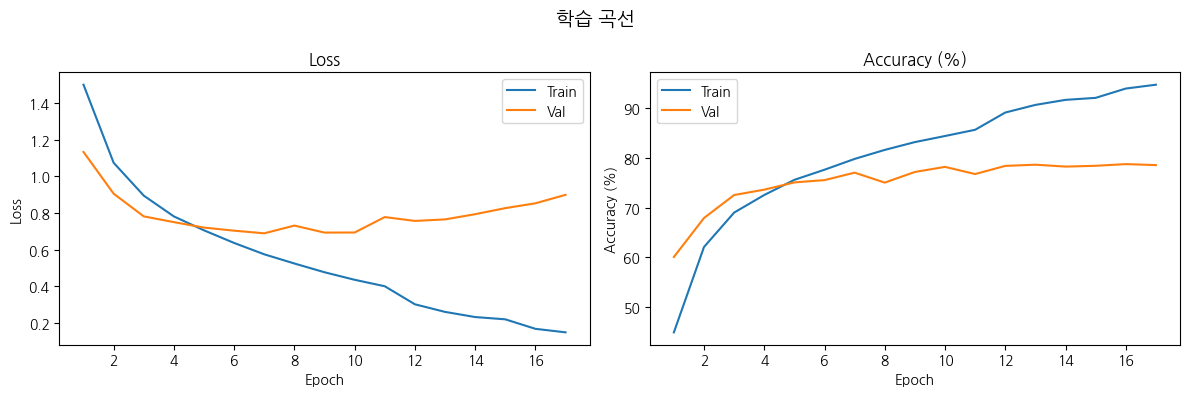

In [10]:

# 실제 학습된 에포크 수 기준으로 x축 생성 (조기 종료 시 NUM_EPOCHS보다 작을 수 있음)
epochs = range(1, len(history["train_loss"]) + 1)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle("학습 곡선", fontsize=14, fontweight="bold")

# 손실 곡선
axes[0].plot(epochs, history["train_loss"], label="Train")
axes[0].plot(epochs, history["val_loss"],   label="Val")
axes[0].set_title("Loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].legend()

# 정확도 곡선
axes[1].plot(epochs, history["train_acc"], label="Train")
axes[1].plot(epochs, history["val_acc"],   label="Val")
axes[1].set_title("Accuracy (%)")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy (%)")
axes[1].legend()

plt.tight_layout()
plt.show()


##### 테스트 평가

In [11]:

test_loss, test_acc = evaluate(test_loader)
print(f"Test Loss: {test_loss:.4f}  |  Test Accuracy: {test_acc:.2f}%")


Test Loss: 0.7241  |  Test Accuracy: 76.35%
